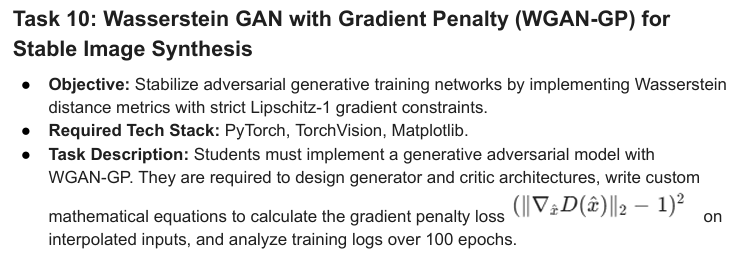

In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [ ]:
image_size = 28
channels = 1

latent_dim = 5

batch_size = 64

epochs = 2 # Changed to 2 epochs for a shorter, easier execution

lr = 0.0002

beta1 = 0.0
beta2 = 0.9

lambda_gp = 10

critic_iterations = 5

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

In [ ]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

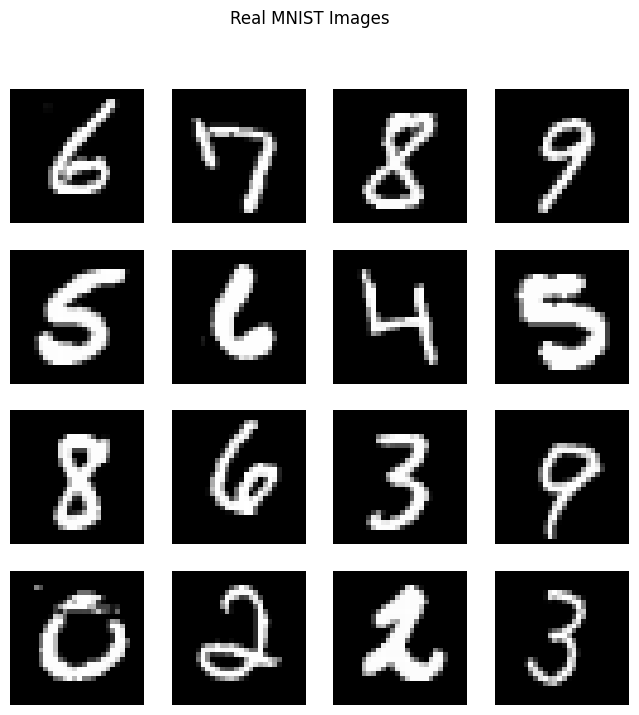

In [ ]:
images, labels = next(
    iter(train_loader)
)

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Real MNIST Images")

plt.show()

In [ ]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(
                latent_dim,
                128 * 7 * 7
            ),

            nn.BatchNorm1d(
                128 * 7 * 7
            ),

            nn.ReLU(True)
        )

        self.deconv = nn.Sequential(

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, z):

        x = self.model(z)

        x = x.view(
            -1,
            128,
            7,
            7
        )

        return self.deconv(x)

In [ ]:
class Critic(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Flatten(),

            nn.Linear(
                128 * 7 * 7,
                1
            )
        )

    def forward(self, x):

        return self.model(x)

In [ ]:
generator = Generator().to(device)

critic = Critic().to(device)

print(generator)

print(critic)

Generator(
  (model): Sequential(
    (0): Linear(in_features=5, out_features=6272, bias=True)
    (1): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)
Critic(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=6272, out_features=1, bias=True)
  )
)


In [ ]:
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=lr,
    betas=(beta1, beta2)
)

optimizer_C = optim.Adam(
    critic.parameters(),
    lr=lr,
    betas=(beta1, beta2)
)

In [ ]:
z = torch.randn(
    16,
    latent_dim,
    device=device
)

In [ ]:
fake_images = generator(z)

print(
    "Generated image shape:",
    fake_images.shape
)

Generated image shape: torch.Size([16, 1, 28, 28])


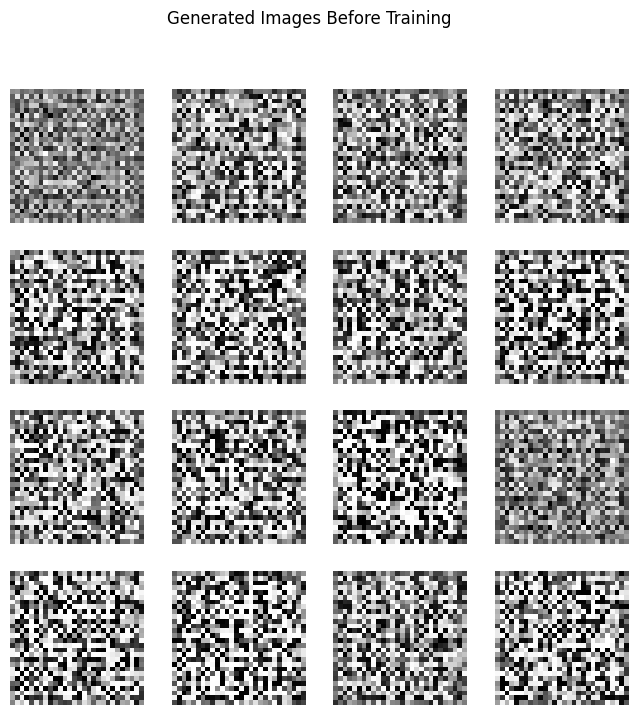

In [ ]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        fake_images[i]
        .detach()
        .cpu()
        .squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Generated Images Before Training"
)

plt.show()

In [ ]:
def gradient_penalty(
    critic,
    real_images,
    fake_images
):

    batch_size = real_images.size(0)

    # Random interpolation coefficient
    alpha = torch.rand(
        batch_size,
        1,
        1,
        1,
        device=device
    )

    # Interpolated images
    interpolated = (
        alpha * real_images
        +
        (1 - alpha) * fake_images
    )

    interpolated.requires_grad_(True)

    # Critic prediction
    critic_output = critic(
        interpolated
    )

    # Calculate gradients
    gradients = torch.autograd.grad(
        outputs=critic_output,
        inputs=interpolated,
        grad_outputs=torch.ones_like(
            critic_output
        ),
        create_graph=True,
        retain_graph=True
    )[0]

    # Flatten gradients
    gradients = gradients.view(
        batch_size,
        -1
    )

    # Gradient norm
    gradient_norm = gradients.norm(
        2,
        dim=1
    )

    # Gradient penalty
    penalty = torch.mean(
        (gradient_norm - 1) ** 2
    )

    return penalty

In [ ]:
real_images = images.to(device)

z = torch.randn(
    real_images.size(0),
    latent_dim,
    device=device
)

fake_images = generator(z)

gp = gradient_penalty(
    critic,
    real_images,
    fake_images
)

print(
    "Gradient Penalty:",
    gp.item()
)

Gradient Penalty: 0.8256423473358154


In [ ]:
def critic_loss(
    real_scores,
    fake_scores,
    gp
):

    return (
        fake_scores.mean()
        -
        real_scores.mean()
        +
        lambda_gp * gp
    )

In [ ]:
def generator_loss(
    fake_scores
):

    return -fake_scores.mean()

In [ ]:
real_scores = critic(
    real_images
)

fake_scores = critic(
    fake_images.detach()
)

gp = gradient_penalty(
    critic,
    real_images,
    fake_images.detach()
)

c_loss = critic_loss(
    real_scores,
    fake_scores,
    gp
)

g_loss = generator_loss(
    critic(fake_images)
)

print(
    "Critic Loss:",
    c_loss.item()
)

print(
    "Generator Loss:",
    g_loss.item()
)

Critic Loss: 8.326616287231445
Generator Loss: -0.031169312074780464


In [ ]:
generator_losses = []

critic_losses = []

gradient_penalties = []

In [46]:
epochs = 2
for epoch in range(epochs):

    for batch_idx, (real_images, _) in enumerate(
        train_loader
    ):

        real_images = real_images.to(
            device
        )

        batch_size_current = (
            real_images.size(0)
        )


        # Train Critic


        for _ in range(
            critic_iterations
        ):

            z = torch.randn(
                batch_size_current,
                latent_dim,
                device=device
            )

            fake_images = generator(z)

            real_scores = critic(
                real_images
            )

            fake_scores = critic(
                fake_images.detach()
            )

            gp = gradient_penalty(
                critic,
                real_images,
                fake_images.detach()
            )

            c_loss = critic_loss(
                real_scores,
                fake_scores,
                gp
            )

            optimizer_C.zero_grad()

            c_loss.backward()

            optimizer_C.step()



        # Train Generator


        z = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_images = generator(z)

        fake_scores = critic(
            fake_images
        )

        g_loss = generator_loss(
            fake_scores
        )

        optimizer_G.zero_grad()

        g_loss.backward()

        optimizer_G.step()



        # Store losses


        generator_losses.append(
            g_loss.item()
        )

        critic_losses.append(
            c_loss.item()
        )

        gradient_penalties.append(
            gp.item()
        )


    print(
        f"Epoch [{epoch+1}/{epochs}] " # Now dynamically uses the updated 'epochs' variable
        f"Generator Loss: {g_loss.item():.4f} "
        f"Critic Loss: {c_loss.item():.4f} "
        f"GP: {gp.item():.4f}"
    )

Epoch [1/2] Generator Loss: -2.8242 Critic Loss: -3.1373 GP: 0.0397
Epoch [2/2] Generator Loss: 0.0524 Critic Loss: -2.9469 GP: 0.0280


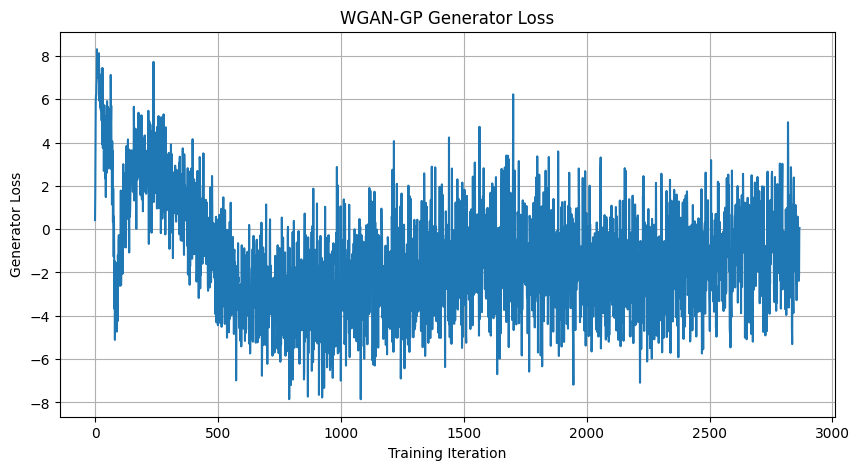

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    generator_losses
)

plt.xlabel("Training Iteration")

plt.ylabel("Generator Loss")

plt.title(
    "WGAN-GP Generator Loss"
)

plt.grid()

plt.show()

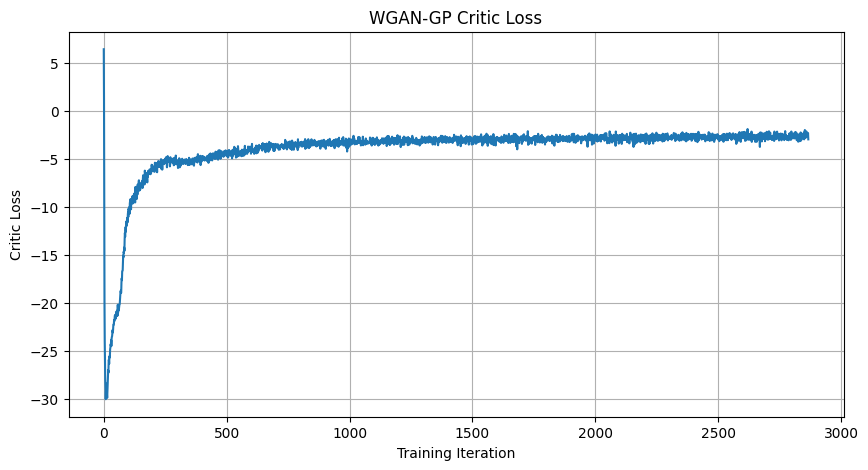

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    critic_losses
)

plt.xlabel("Training Iteration")

plt.ylabel("Critic Loss")

plt.title(
    "WGAN-GP Critic Loss"
)

plt.grid()

plt.show()

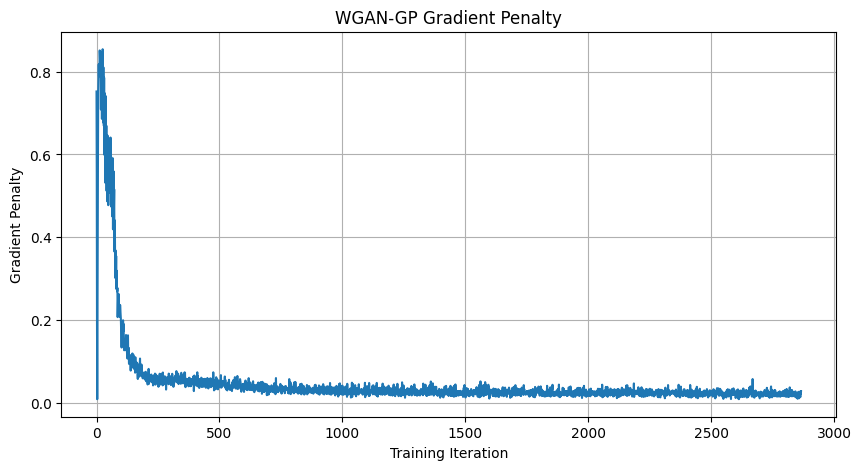

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(
    gradient_penalties
)

plt.xlabel("Training Iteration")

plt.ylabel(
    "Gradient Penalty"
)

plt.title(
    "WGAN-GP Gradient Penalty"
)

plt.grid()

plt.show()

In [50]:
generator.eval()

with torch.no_grad():

    z = torch.randn(
        16,
        latent_dim,
        device=device
    )

    generated_images = generator(z)

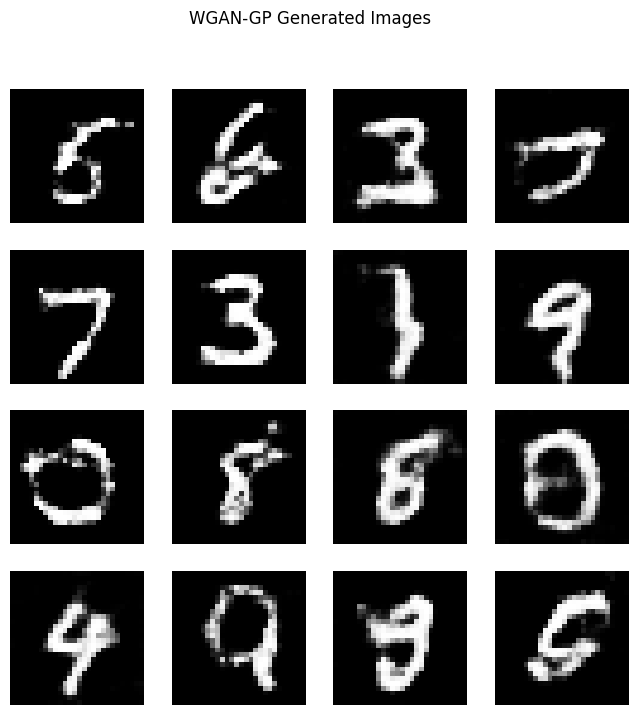

In [51]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated_images[i]
        .cpu()
        .squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "WGAN-GP Generated Images"
)

plt.show()

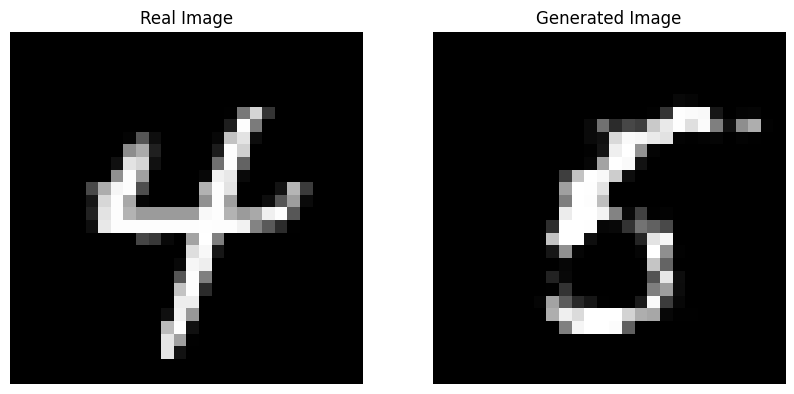

In [52]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    real_images[0]
    .cpu()
    .squeeze(),
    cmap="gray"
)

plt.title("Real Image")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    generated_images[0]
    .cpu()
    .squeeze(),
    cmap="gray"
)

plt.title("Generated Image")

plt.axis("off")

plt.show()